<font size="+3">AF3 benchmark on TCR:epitope interactions</font> <br>
-> AF3 template search only with input sequence

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from sklearn.metrics import roc_curve, roc_auc_score
import pickle

import math
from functools import reduce
import re

from Bio.SeqUtils import seq1
from scipy.stats import spearmanr

from sklearn.decomposition import PCA
from Bio.PDB import MMCIFParser, PDBParser, PDBIO, MMCIFIO, Superimposer

# AF3 input

/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_10948/471088666.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_pos_sub = (df_pos.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)))
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_10948/471088666.py:27: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_neg_sub = (df_neg.groupby('E

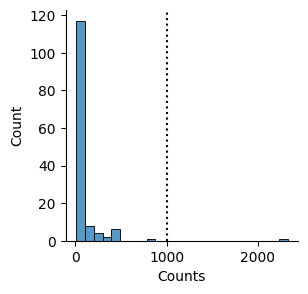

In [8]:
topdir = '../260330_af3_benchmark/Supplementary_Tables'


df = pd.read_csv(f'{topdir}/Supplementary_Table_1.csv')
df = df.drop(columns=['data_usage', 'CV_id'])
df = df.drop_duplicates()

df_pos = df[(df['dataset_source'] == 'Public Paired Data') & (df['Label'] == 1)]
df_neg = df[(df['dataset_source'] == 'Public TCRs with undetermined specificities') & (df['Label'] == 0)]

counts = df_pos['Epitope'].value_counts().reset_index()
counts.columns = ['Epitope', 'Counts']

fig, ax = plt.subplots(1,1,figsize=(3,3))
sns.histplot(data=counts, x='Counts', ax=ax)
ax.axvline(1000, color='black', linestyle=':')
sns.despine()

# subsample positives n > 1000
df_pos_sub = (df_pos.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 1000), random_state=42)))
df_pos_sub.to_csv('positives.csv', index=False)

# how many positives per epitope after subsampling
pos_counts = df_pos_sub['Epitope'].value_counts()

# sample matching number of negatives per epitope
df_neg_sub = (df_neg.groupby('Epitope', group_keys=False).apply(lambda x: x.sample(n=min(len(x), pos_counts.get(x.name, 0)), random_state=42)).reset_index(drop=True))
df_neg_sub.to_csv('negatives.csv', index=False)

In [2]:
topdirs = ['standard', 'mod_template_search']

for topdir in topdirs:
    os.makedirs(topdir, exist_ok=True)

    batches = ['positives', 'negatives']
    exclude_mhc = ['DRB10101', 'DRB10701', 'DRB11501', 'na']

    # top 10 epitopes with most positives, subsampled to 50
    pos_counts = pd.read_csv('positives.csv')['Epitope'].value_counts()
    top10 = pos_counts.head(10).index.tolist()

    for batch in batches:
        ndir = f'{topdir}/{batch}'
        os.makedirs(ndir, exist_ok=True)
        df = pd.read_csv(f'{batch}.csv')
        df = df.drop(columns=['Label', 'dataset_source'])
        df['peptide'] = df['Epitope'].str.split('_').str[1]
        df['MHC'] = df['Epitope'].str.split('_').str[0]
        
        # exclude unclear mhcs
        df = df[~df['MHC'].isin(exclude_mhc)]

        # split alpha/beta if present
        mhc_split = df['MHC'].str.split('-', n=1, expand=True)

        # first allele always exists
        df['MHC_allele_a'] = 'HLA_' + mhc_split[0]

        # second allele only exists for entries with '-'
        df['MHC_allele_b'] = mhc_split[1]
        df['MHC_allele_b'] = 'HLA_' + df['MHC_allele_b'].fillna('NA')
        df.loc[mhc_split[1].isna(), 'MHC_allele_b'] = 'NA'
        df = df.drop(columns=['MHC'])

        # for now only class I
        df = df[df['MHC_allele_b'] == 'NA']
        df = df.drop(columns=['MHC_allele_b'])

        # keep top 10 epitopes and subsample to 50
        df = (df[df['Epitope'].isin(top10)]
                .groupby('Epitope', group_keys=False)
                .apply(lambda x: x.sample(n=min(len(x), 50), random_state=42))
                .reset_index(drop=True))

        df = df.drop(columns=['Epitope'])

        tcr_ids = np.array([f'tcr_{i+1:05d}' for i in range(len(df))])
        df.insert(0, 'id', tcr_ids)

        df.to_csv(f'{ndir}/AF3_class_I.csv', index=False)
        print(len(df))

450
450
450
450


/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_17385/2225685315.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 50), random_state=42))
/var/folders/mg/jhh2rvf11vd1jd013_6qqg200000gn/T/ipykernel_17385/2225685315.py:43: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(len(x), 50), random_state=42))
/var/folders/mg/jhh2rvf11v

# Analyze AF3 output

In [3]:
topdirs = ['standard', 'mod_template_search']
batches = ['positives', 'negatives']

for topdir in topdirs:
    lst = []
    for batch in batches:
        df_input = pd.read_csv(f'{topdir}/{batch}/AF3_class_I_input.txt', sep='\t')[['id', 'peptide', 'MHC_allele_a']]
        df_input['epitope'] = df_input['MHC_allele_a'].str[4:] + '_' + df_input['peptide']
       
        df_output = pd.read_csv(f'{topdir}/{batch}/AF3_class_I_output.txt', sep='\t')[['id', 'AF3_iptm_pair_mean']]
        
        df = pd.merge(df_input, df_output, on='id')
        df['batch'] = batch
        lst.append(df)

    df = pd.concat(lst)
    df.to_csv(f'{topdir}/AF3_class_I_output.csv', index=False)
    print(df.head())

          id     peptide MHC_allele_a           epitope  AF3_iptm_pair_mean  \
0  tcr_00001  TTDPSFLGRY    HLA_A0101  A0101_TTDPSFLGRY              0.8100   
1  tcr_00002  TTDPSFLGRY    HLA_A0101  A0101_TTDPSFLGRY              0.2050   
2  tcr_00003  TTDPSFLGRY    HLA_A0101  A0101_TTDPSFLGRY              0.7800   
3  tcr_00004  TTDPSFLGRY    HLA_A0101  A0101_TTDPSFLGRY              0.1300   
4  tcr_00005  TTDPSFLGRY    HLA_A0101  A0101_TTDPSFLGRY              0.6675   

       batch  
0  positives  
1  positives  
2  positives  
3  positives  
4  positives  
          id     peptide MHC_allele_a           epitope  AF3_iptm_pair_mean  \
0  tcr_00001  TTDPSFLGRY    HLA_A0101  A0101_TTDPSFLGRY              0.8100   
1  tcr_00002  TTDPSFLGRY    HLA_A0101  A0101_TTDPSFLGRY              0.2050   
2  tcr_00003  TTDPSFLGRY    HLA_A0101  A0101_TTDPSFLGRY              0.7800   
3  tcr_00004  TTDPSFLGRY    HLA_A0101  A0101_TTDPSFLGRY              0.1300   
4  tcr_00005  TTDPSFLGRY    HLA_A0101  A

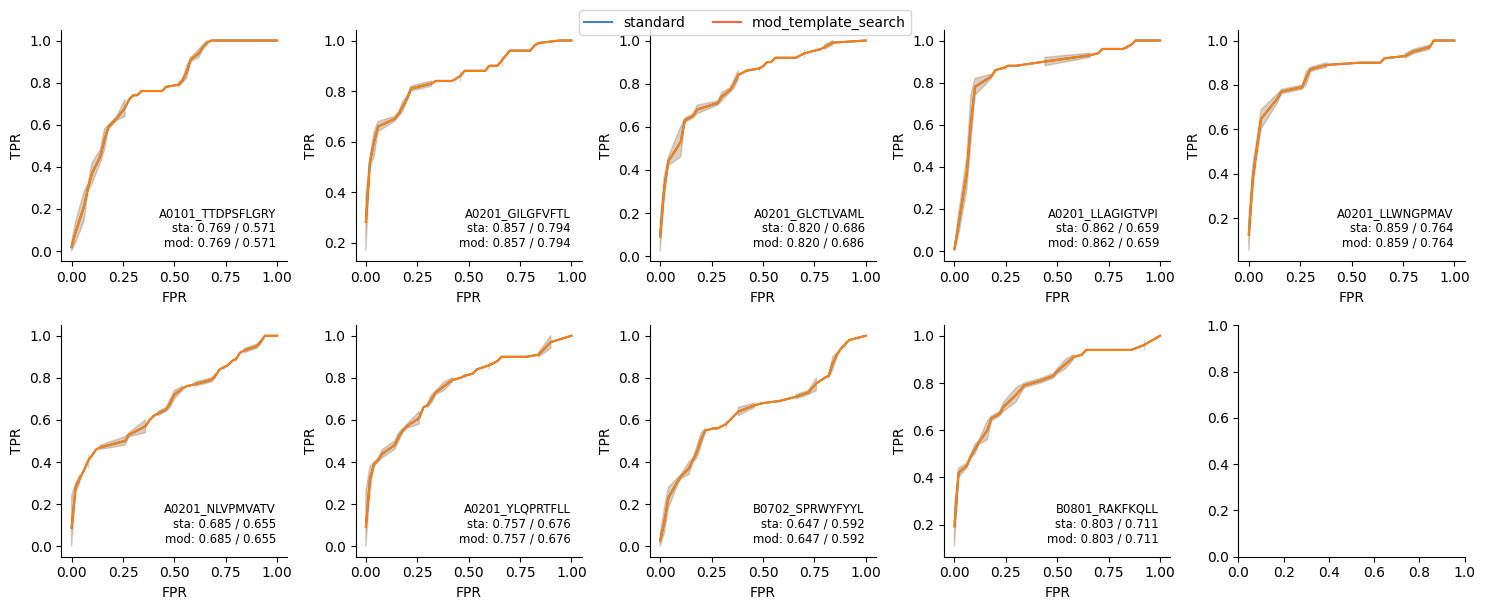

In [20]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Load both dataframes upfront
dfs = {topdir: pd.read_csv(f'{topdir}/AF3_class_I_output.csv') for topdir in topdirs}

epitopes = dfs['standard']['epitope'].unique()  # assume same epitopes in both

for cnt, name in enumerate(epitopes):
    row = cnt // 5
    col_idx = cnt % 5
    ax = axes[row, col_idx]

    label_lines = [name]

    for topdir, df in dfs.items():
        group = df[df['epitope'] == name]

        pos_mask = group['batch'] == 'positives'
        neg_mask = group['batch'] == 'negatives'

        y_true = np.concatenate([np.ones(pos_mask.sum()), np.zeros(neg_mask.sum())])

        col = 'AF3_iptm_pair_mean'  # pick the score col to plot per topdir
        scores_pos = group.loc[pos_mask, col].values
        scores_neg = group.loc[neg_mask, col].values
        y_scores = np.concatenate([scores_pos, scores_neg])

        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc_full = roc_auc_score(y_true, y_scores)
        auc01    = roc_auc_score(y_true, y_scores, max_fpr=0.1)

        sns.lineplot(x=fpr, y=tpr, ax=ax, label=topdir)

        label_lines.append(f"{topdir[:3]}: {auc_full:.3f} / {auc01:.3f}")
    

    ax.text(0.95, 0.05, '\n'.join(label_lines),
            transform=ax.transAxes, ha='right', va='bottom', fontsize='small')
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.get_legend().remove()
    sns.despine()


fig.legend(handles=handles, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()